In [ ]:
import os
os.chdir('f:\\Projects\\GeneIndex')

Current working directory: f:\Projects\GeneIndex


In [3]:
from src.u1_downloader.images_downloader import download_group, get_all_gids
from src.u1_downloader.images_loader import load_all
import pandas as pd
from pathlib import Path
import torch
import torchvision
import matplotlib.pyplot as plt
import torchvision.transforms.functional as F
from PIL import Image
from tqdm import tqdm
from torchvision.transforms import v2
import h5py
import numpy as np
import shutil

In [4]:
TEMP_PATH = Path('src/m0_ae/dataset/temp')
OUT_PATH = Path('src/m0_ae/dataset/train_100k')

In [5]:
gids = get_all_gids()

In [6]:
PATCH_SIZE = 512

def patchify(input_folder, h5_path, batch_size=100, pathes_per_scan=5):
    all_files = [os.path.join(input_folder, f) for f in os.listdir(input_folder) if f.endswith(('.jpg', '.png'))]
    
    with h5py.File(h5_path, 'w') as f:
        dst = f.create_dataset(
            'patches', 
            shape=(0, 3, PATCH_SIZE, PATCH_SIZE), 
            maxshape=(None, 3, PATCH_SIZE, PATCH_SIZE), 
            dtype=np.uint8,
            chunks=(1, 3, PATCH_SIZE, PATCH_SIZE)
        )
        
        temp_batch = []
        total_saved = 0
        
        for i, img_path in tqdm(enumerate(all_files), total=len(all_files), desc='Patching images'):
            img = Image.open(img_path).convert("RGB")
            img = img.resize((img.width // 2, img.height // 2))
            
            x_all = np.random.randint(0,img.width - PATCH_SIZE, size=(pathes_per_scan,))
            y_all = np.random.randint(0,img.height - PATCH_SIZE, size=(pathes_per_scan,))

            for x,y in zip(x_all, y_all):
                box = (x, y, x + PATCH_SIZE, y + PATCH_SIZE)
                patch = img.crop(box)
                    
                patch_np = np.array(patch).transpose(2, 0, 1)
                temp_batch.append(patch_np)
                    
                if len(temp_batch) >= batch_size:
                    arr_batch = np.array(temp_batch)
                        
                    dst.resize(total_saved + len(arr_batch), axis=0)
                    dst[total_saved:] = arr_batch
                        
                    total_saved += len(arr_batch)
                    temp_batch = []
                
        if len(temp_batch) > 0:
            arr_batch = np.array(temp_batch)
            dst.resize(total_saved + len(arr_batch), axis=0)
            dst[total_saved:] = arr_batch
            total_saved += len(arr_batch)

    print(f"Created file {h5_path} with {total_saved} patches.")

In [ ]:
def do_shard(gid): 
    if not TEMP_PATH.exists():
        os.mkdir(TEMP_PATH)

    download_group(str(TEMP_PATH), gid, percentage=0.1)
    patchify(TEMP_PATH, OUT_PATH / f'gid{gid}.h5', pathes_per_scan=5)

    shutil.rmtree(TEMP_PATH)

for gid in pd.Series(gids).sample(1):
    do_shard(gid)

Found 50 subgroups in 25


Patching images: 100%|██████████| 1258/1258 [02:58<00:00,  7.05it/s]


Created file src\m0_ae\dataset\train_100k\gid25.h5 with 6290 patches.


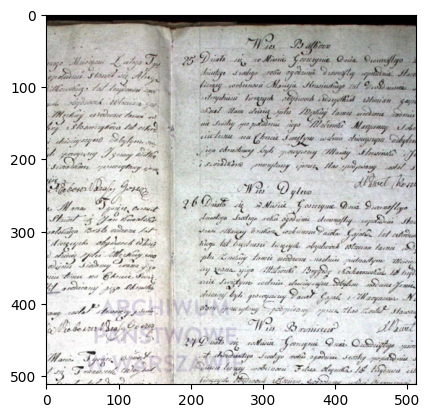

In [20]:
import h5py

with h5py.File(OUT_PATH / "gid25.h5", "r") as f:
    images = f["patches"]

    idx = 15
    image = images[idx]

    plt.imshow(image.transpose(1,2,0))
    plt.show()